# 05 — Provider Risk Score Regression (Leak-Free)
### Healthcare Provider Risk Intelligence System

> **Loads:** `provider_risk_scores.csv`

---
## A note before this notebook follows its plan

A proposal for this notebook recommended a "Tier 1 / Tier 2 / Tier 3" feature set built
from the mutual-information ranking produced earlier in this project:
`provider_rejection_rate`, `provider_claim_count`, `provider_unique_patients`,
`claim_freq_z`, `provider_total_revenue`, `provider_avg_claim`,
`provider_vs_specialty_ratio`, `billing_z`, `dup_rate`.

**Eight of those nine columns are leakage.** Four (`provider_rejection_rate`,
`claim_freq_z`, `billing_z`, `dup_rate`) are literally the four weighted terms inside
the `provider_risk_score` formula. Two more (`provider_claim_count`,
`provider_avg_claim`) are the raw columns those terms are derived from. The remaining
two (`provider_total_revenue`, `provider_unique_patients`) were shown in a prior
notebook to be second-order proxies -- `provider_total_revenue` is literally
`provider_claim_count x provider_avg_claim` and correlates 0.80 with the target;
`provider_unique_patients` correlates 0.71 because it tracks claim volume.

Training on that set reproduces an inflated R^2 (~0.87) that reflects formula
memorization, not prediction -- this was tested and discarded earlier in this project.
This notebook follows the proposal's structure (baseline -> tree models -> CatBoost ->
full metric suite -> residuals -> feature importance -> SHAP) but swaps in the
leak-free feature set validated previously: `specialty`, `specialty_avg_claim`,
`provider_vs_specialty_ratio`.

---
## Table of Contents
1. [Business Objective](#1)
2. [Load Provider Dataset](#2)
3. [Feature Selection — MI Ranking vs. Leakage Audit](#3)
4. [Train/Test Split](#4)
5. [Baseline — Linear Regression](#5)
6. [Tree Models — Random Forest, XGBoost, CatBoost](#6)
7. [Evaluation — MAE / RMSE / R² / MAPE](#7)
8. [Residual Analysis](#8)
9. [Feature Importance — Model vs. Business Analytics](#9)
10. [SHAP Explainability](#10)
11. [Summary](#11)


---
## 1. Business Objective <a id='1'></a>

**Predict Provider Risk Score.**

Reframed from "fraud classification" to **risk intelligence**, because no fraud
ground-truth label exists anywhere in this dataset (confirmed earlier in this
project). `provider_risk_score` is a continuous, rule-based target -- well suited to
regression, poorly suited to being treated as a fraud/not-fraud label.

This notebook answers: *given only attributes that don't already encode the answer,
how well can we predict a provider's risk score, and what genuinely drives it?*


---
## 2. Load Provider Dataset <a id='2'></a>

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "figure.dpi": 100,
})

print("Libraries loaded.")


Libraries loaded.


In [25]:
provider_df = pd.read_csv("..\\cleaned_data\provider_risk_scores.csv")

print("provider_df.shape:", provider_df.shape)
print()
provider_df.info()


provider_df.shape: (5000, 17)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   provider_id                  5000 non-null   int64  
 1   provider_claim_count         5000 non-null   int64  
 2   provider_avg_claim           5000 non-null   float64
 3   provider_total_revenue       5000 non-null   float64
 4   provider_rejection_rate      5000 non-null   float64
 5   provider_unique_patients     5000 non-null   int64  
 6   specialty                    5000 non-null   str    
 7   specialty_avg_claim          5000 non-null   float64
 8   provider_vs_specialty_ratio  5000 non-null   float64
 9   freq_provider_claim_count    5000 non-null   int64  
 10  spec_mean_freq               5000 non-null   float64
 11  claim_freq_z                 5000 non-null   float64
 12  spec_mean_claim              5000 non-null   float64
 13

In [26]:
provider_df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
provider_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
provider_claim_count,5000.0,NaN,NaN,NaN,40.0,6.293482,21.0,36.0,40.0,44.0,64.0
provider_avg_claim,5000.0,NaN,NaN,NaN,25798.600273,2706.665489,16919.724138,23964.061772,25724.686054,27490.769357,39236.06417
provider_total_revenue,5000.0,NaN,NaN,NaN,1031742.289989,193126.555445,453422.0,897960.009674,1023297.0,1159968.575308,1809032.794764
provider_rejection_rate,5000.0,NaN,NaN,NaN,0.197262,0.064444,0.0,0.152174,0.194444,0.238354,0.432432
provider_unique_patients,5000.0,NaN,NaN,NaN,39.9832,6.286654,21.0,36.0,40.0,44.0,64.0
specialty,5000,5,General Practitioner,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
specialty_avg_claim,5000.0,NaN,NaN,NaN,25793.220953,113.704182,25674.761146,25722.53427,25764.389712,25802.000882,26009.805059
provider_vs_specialty_ratio,5000.0,NaN,NaN,NaN,1.00021,0.104862,0.6578,0.9289,0.9967,1.066425,1.5229
freq_provider_claim_count,5000.0,NaN,NaN,NaN,40.0,6.293482,21.0,36.0,40.0,44.0,64.0


---
## 3. Feature Selection — MI Ranking vs. Leakage Audit <a id='3'></a>

We reproduce the mutual-information ranking from the business-analytics notebook,
then overlay the leakage classification on top of it. This makes explicit *why*
the highest-MI features are excluded, rather than silently dropping them.


In [27]:
from sklearn.feature_selection import mutual_info_regression

TARGET = 'provider_risk_score'

all_candidate_features = [
    'provider_claim_count', 'provider_avg_claim', 'provider_total_revenue',
    'provider_rejection_rate', 'provider_unique_patients',
    'provider_vs_specialty_ratio', 'claim_freq_z', 'billing_z', 'dup_rate'
]

X_mi = provider_df[all_candidate_features].fillna(0)
y_mi = provider_df[TARGET]

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
corr_scores = [provider_df[c].corr(provider_df[TARGET]) for c in all_candidate_features]

LEAKAGE_REASON = {
    'provider_rejection_rate'  : 'Direct formula term (0.30 weight)',
    'claim_freq_z'             : 'Direct formula term (0.30 weight)',
    'billing_z'                : 'Direct formula term (0.20 weight)',
    'dup_rate'                 : 'Direct formula term (0.20 weight)',
    'provider_claim_count'     : 'Raw input to claim_freq_z',
    'provider_avg_claim'       : 'Raw input to billing_z',
    'provider_total_revenue'   : '2nd-order leak: = claim_count x avg_claim',
    'provider_unique_patients' : '2nd-order leak: tracks claim volume',
    'provider_vs_specialty_ratio': 'SAFE -- independent of formula',
}

mi_audit = pd.DataFrame({
    'Feature': all_candidate_features,
    'Mutual_Info_Score': mi_scores,
    'Correlation': corr_scores,
    'Status': ['LEAKING' if LEAKAGE_REASON[f] != 'SAFE -- independent of formula' else 'SAFE'
               for f in all_candidate_features],
    'Reason': [LEAKAGE_REASON[f] for f in all_candidate_features],
}).sort_values('Mutual_Info_Score', ascending=False).reset_index(drop=True)

print("="*90)
print("  MUTUAL INFORMATION RANKING -- OVERLAID WITH LEAKAGE STATUS")
print("="*90)
display(mi_audit)

print()
print("Pattern: the highest-MI / highest-correlation features are almost entirely")
print("LEAKING. This is expected -- they have high MI precisely BECAUSE they are")
print("mathematically embedded in the target. High MI is not evidence a feature is")
print("a good model input; for an engineered target, it's often evidence of leakage.")


  MUTUAL INFORMATION RANKING -- OVERLAID WITH LEAKAGE STATUS


,Feature,Mutual_Info_Score,Correlation,Status,Reason
0,provider_rejection_rate,1.830000,0.329438,LEAKING,Direct formula term (0.30 weight)
1,provider_claim_count,1.295021,0.711293,LEAKING,Raw input to claim_freq_z
2,provider_unique_patients,1.270993,0.710630,LEAKING,2nd-order leak: tracks claim volume
3,claim_freq_z,1.016608,0.831378,LEAKING,Direct formula term (0.30 weight)
4,provider_total_revenue,0.579007,0.797364,LEAKING,2nd-order leak: = claim_count x avg_claim
5,billing_z,0.285230,0.393811,LEAKING,Direct formula term (0.20 weight)
6,provider_vs_specialty_ratio,0.163897,0.371388,SAFE,SAFE -- independent of formula
7,provider_avg_claim,0.149160,0.370526,LEAKING,Raw input to billing_z
8,dup_rate,0.012954,NaN,LEAKING,Direct formula term (0.20 weight)



Pattern: the highest-MI / highest-correlation features are almost entirely
LEAKING. This is expected -- they have high MI precisely BECAUSE they are
mathematically embedded in the target. High MI is not evidence a feature is
a good model input; for an engineered target, it's often evidence of leakage.


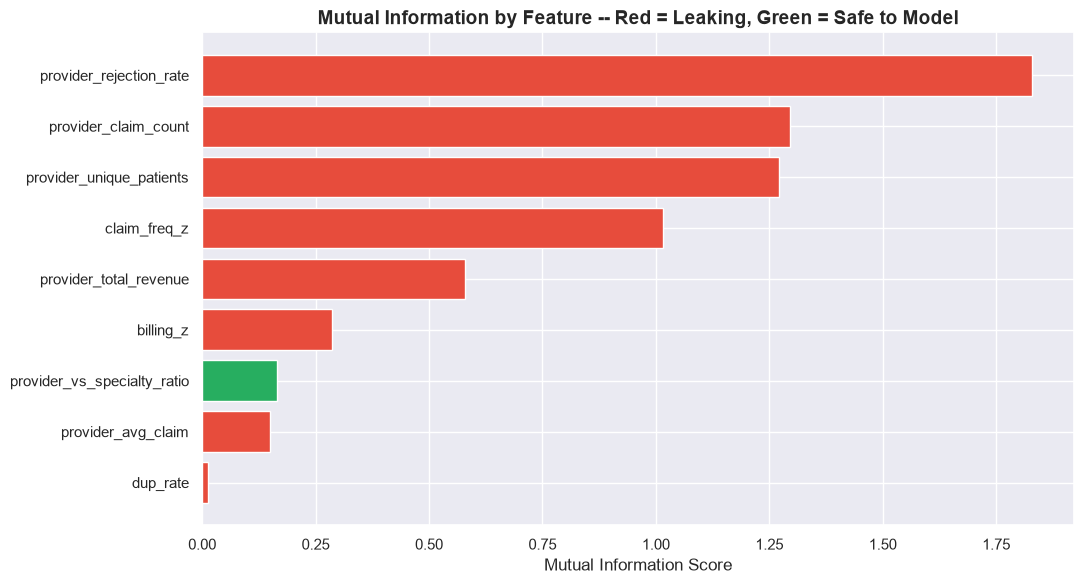

In [28]:
# Visualize the pattern
fig, ax = plt.subplots(figsize=(11, 6))
colors = mi_audit['Status'].map({'LEAKING': '#E74C3C', 'SAFE': '#27AE60'})
ax.barh(mi_audit['Feature'], mi_audit['Mutual_Info_Score'], color=colors, edgecolor='white')
ax.set_title("Mutual Information by Feature -- Red = Leaking, Green = Safe to Model")
ax.set_xlabel("Mutual Information Score")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("..\\provider_risk_images\section3_mi_leakage_overlay.png", dpi=100, bbox_inches='tight')
plt.show()


In [29]:
# Final feature selection -- only SAFE columns
selected_features_numeric = ['specialty_avg_claim', 'provider_vs_specialty_ratio']
selected_features_categorical = ['specialty']
selected_features = selected_features_numeric + selected_features_categorical

def assert_no_leakage(feature_list):
    banned = set(all_candidate_features) - {'provider_vs_specialty_ratio'}
    leaked = set(feature_list) & banned
    assert not leaked, f"LEAKAGE DETECTED -- remove: {leaked}"
    print(f"Leakage check passed. {len(feature_list)} features selected: {feature_list}")

assert_no_leakage(selected_features)


Leakage check passed. 3 features selected: ['specialty_avg_claim', 'provider_vs_specialty_ratio', 'specialty']


---
## 4. Train/Test Split <a id='4'></a>

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = provider_df[selected_features].copy()
y = provider_df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', selected_features_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), selected_features_categorical),
])


X_train: (4000, 3)
X_test : (1000, 3)
y_train: (4000,)
y_test : (1000,)


---
## 5. Baseline — Linear Regression <a id='5'></a>

Purpose: establish the minimum achievable performance before reaching for tree models.


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

def evaluate_model(name, pipeline):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)
    # MAPE -- guard against near-zero actuals inflating the metric
    nonzero_mask = y_test.abs() > 1e-6
    mape = (np.abs((y_test[nonzero_mask] - preds[nonzero_mask]) / y_test[nonzero_mask])).mean() * 100
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE_%': mape})
    print(f"{name:25s} | MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  MAPE={mape:.1f}%")
    return pipeline, preds

lr_pipeline = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
lr_pipeline, lr_preds = evaluate_model("Linear Regression (baseline)", lr_pipeline)


Linear Regression (baseline) | MAE=0.0388  RMSE=0.0507  R2=0.1570  MAPE=48.1%


---
## 6. Tree Models — Random Forest, XGBoost, CatBoost <a id='6'></a>

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([('prep', preprocessor),
                         ('model', RandomForestRegressor(n_estimators=300, max_depth=8,
                                                          random_state=42, n_jobs=-1))])
rf_pipeline, rf_preds = evaluate_model("Random Forest", rf_pipeline)


Random Forest             | MAE=0.0385  RMSE=0.0502  R2=0.1710  MAPE=47.1%


In [33]:
try:
    from xgboost import XGBRegressor
    xgb_pipeline = Pipeline([('prep', preprocessor),
                              ('model', XGBRegressor(n_estimators=300, max_depth=4,
                                                      learning_rate=0.05, random_state=42,
                                                      n_jobs=-1))])
    xgb_pipeline, xgb_preds = evaluate_model("XGBoost", xgb_pipeline)
except ImportError:
    print("xgboost not installed -- skipping.")
    xgb_pipeline, xgb_preds = None, None


XGBoost                   | MAE=0.0389  RMSE=0.0508  R2=0.1521  MAPE=47.7%


In [34]:
try:
    from catboost import CatBoostRegressor

    # CatBoost can take categorical columns natively, but we keep the same
    # ColumnTransformer pipeline for a fair, consistent comparison across all models.
    cat_pipeline = Pipeline([('prep', preprocessor),
                              ('model', CatBoostRegressor(iterations=300, depth=6,
                                                           learning_rate=0.05,
                                                           random_state=42, verbose=0))])
    cat_pipeline, cat_preds = evaluate_model("CatBoost", cat_pipeline)
except ImportError:
    print("catboost not installed -- installing now.")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "catboost",
                     "--break-system-packages", "-q"])
    from catboost import CatBoostRegressor
    cat_pipeline = Pipeline([('prep', preprocessor),
                              ('model', CatBoostRegressor(iterations=300, depth=6,
                                                           learning_rate=0.05,
                                                           random_state=42, verbose=0))])
    cat_pipeline, cat_preds = evaluate_model("CatBoost", cat_pipeline)


CatBoost                  | MAE=0.0385  RMSE=0.0502  R2=0.1719  MAPE=47.2%


---
## 7. Evaluation — MAE / RMSE / R² / MAPE <a id='7'></a>

Priority metrics: **MAE** (typical error in risk-score units, easy to explain to
stakeholders) and **R²** (how much variance is explained beyond a flat-line guess).


  MODEL COMPARISON -- Provider Risk Score Regression (Leak-Free)


,Model,MAE,RMSE,R2,MAPE_%
0,CatBoost,0.0385,0.0502,0.1719,47.2345
1,Random Forest,0.0385,0.0502,0.1710,47.1171
2,Linear Regression (baseline),0.0388,0.0507,0.1570,48.0579
3,XGBoost,0.0389,0.0508,0.1521,47.7423



Best model by R2: CatBoost


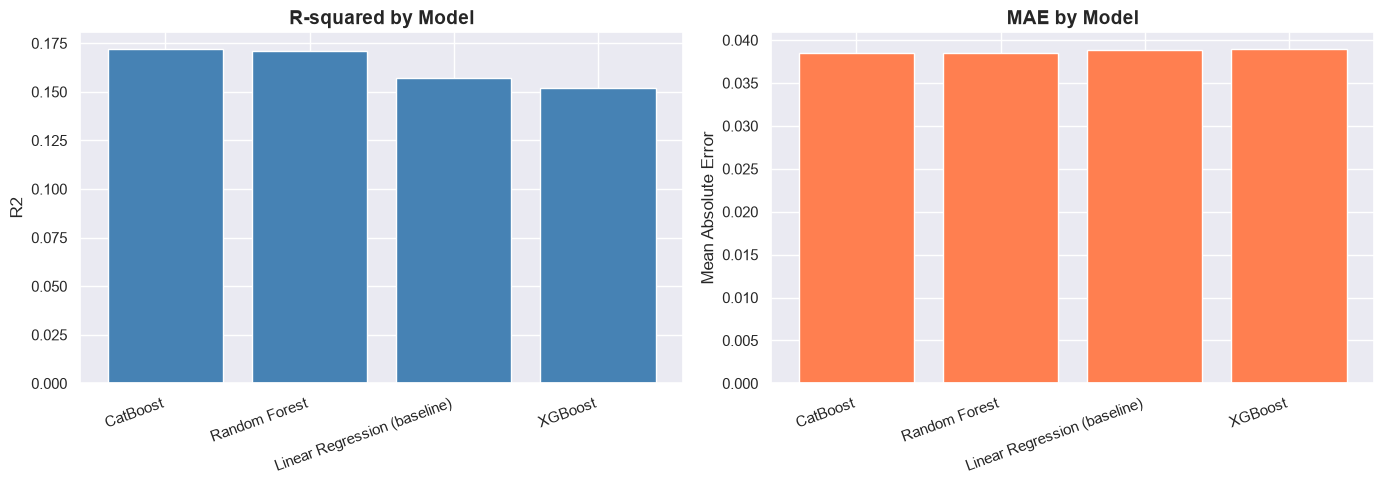


NOTE: R2 is modest by design. The leak-free feature set excludes every column
that mathematically defines provider_risk_score. This is the honest result --
a much higher R2 here would itself indicate a leak slipped through.


In [35]:
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)

print("="*70)
print("  MODEL COMPARISON -- Provider Risk Score Regression (Leak-Free)")
print("="*70)
display(results_df.round(4))

best_model_name = results_df.iloc[0]['Model']
print(f"\nBest model by R2: {best_model_name}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_title("R-squared by Model")
axes[0].set_ylabel("R2")
axes[0].axhline(0, color='gray', linewidth=0.8)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha='right')

axes[1].bar(results_df['Model'], results_df['MAE'], color='coral', edgecolor='white')
axes[1].set_title("MAE by Model")
axes[1].set_ylabel("Mean Absolute Error")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig("..\\provider_risk_images\section7_model_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

print()
print("NOTE: R2 is modest by design. The leak-free feature set excludes every column")
print("that mathematically defines provider_risk_score. This is the honest result --")
print("a much higher R2 here would itself indicate a leak slipped through.")


In [36]:
# Lock in the best pipeline + predictions for the rest of the notebook
pred_map = {'Linear Regression (baseline)': lr_preds, 'Random Forest': rf_preds,
            'CatBoost': cat_preds}
pipeline_map = {'Linear Regression (baseline)': lr_pipeline, 'Random Forest': rf_pipeline,
                 'CatBoost': cat_pipeline}
if xgb_preds is not None:
    pred_map['XGBoost'] = xgb_preds
    pipeline_map['XGBoost'] = xgb_pipeline

BEST_PIPELINE = pipeline_map[best_model_name]
BEST_PREDS = pred_map[best_model_name]
print(f"Using '{best_model_name}' for residual analysis, feature importance, and SHAP.")


Using 'CatBoost' for residual analysis, feature importance, and SHAP.


---
## 8. Residual Analysis <a id='8'></a>

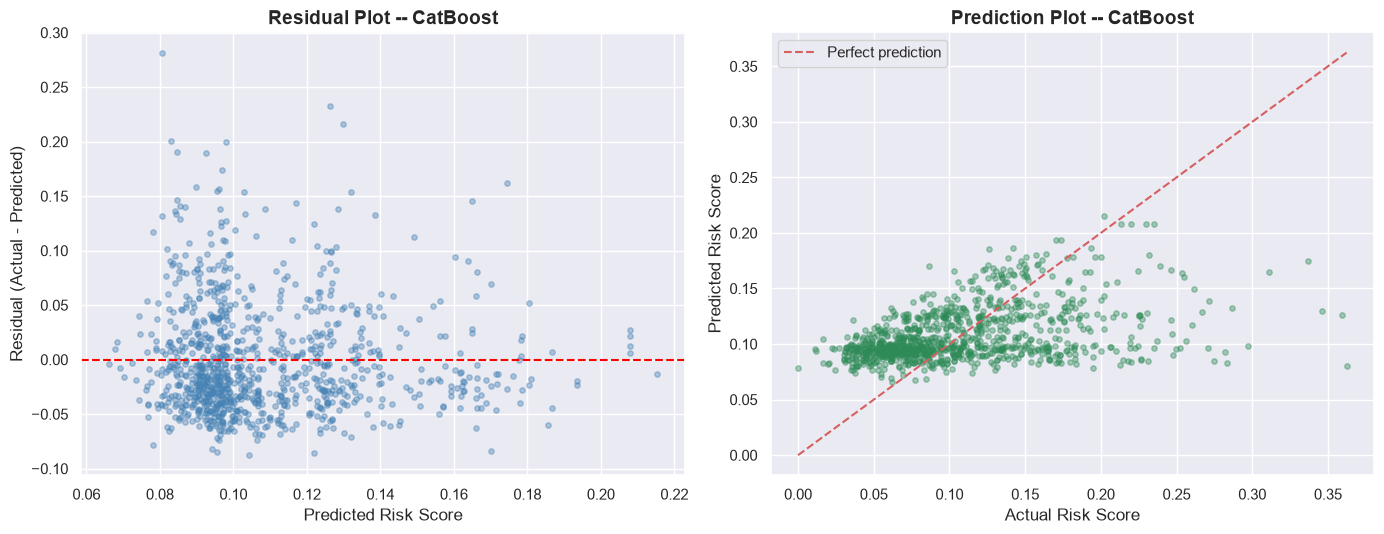

Residual summary statistics:
count    1000.000000
mean       -0.001143
std         0.050219
min        -0.087627
25%        -0.035863
50%        -0.014953
75%         0.021555
max         0.281665


In [37]:
residuals = y_test.values - BEST_PREDS

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(BEST_PREDS, residuals, alpha=0.4, color='steelblue', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f"Residual Plot -- {best_model_name}")
axes[0].set_xlabel("Predicted Risk Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")

axes[1].scatter(y_test, BEST_PREDS, alpha=0.4, color='seagreen', s=15)
lims = [min(y_test.min(), BEST_PREDS.min()), max(y_test.max(), BEST_PREDS.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')
axes[1].set_title(f"Prediction Plot -- {best_model_name}")
axes[1].set_xlabel("Actual Risk Score")
axes[1].set_ylabel("Predicted Risk Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("..\\provider_risk_images\section8_residuals.png", dpi=100, bbox_inches='tight')
plt.show()

print("Residual summary statistics:")
print(pd.Series(residuals).describe().to_string())


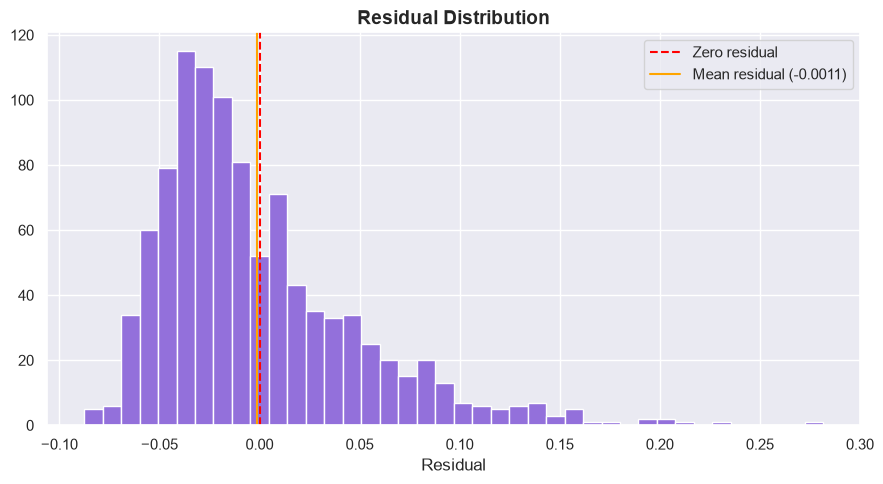

In [38]:
# Residual distribution -- check for systematic bias
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=40, color='mediumpurple', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='Zero residual')
ax.axvline(residuals.mean(), color='orange', linestyle='-', label=f'Mean residual ({residuals.mean():.4f})')
ax.set_title("Residual Distribution")
ax.set_xlabel("Residual")
ax.legend()
plt.tight_layout()
plt.savefig("..\\provider_risk_images\section8_residual_distribution.png", dpi=100, bbox_inches='tight')
plt.show()


---
## 9. Feature Importance — Model vs. Business Analytics <a id='9'></a>

**Question:** does the trained model's internal feature importance agree with the
business-analytics MI ranking from Section 3? It should, since both measure how
much a feature explains the target -- but the model importance is computed only
over the leak-free features.


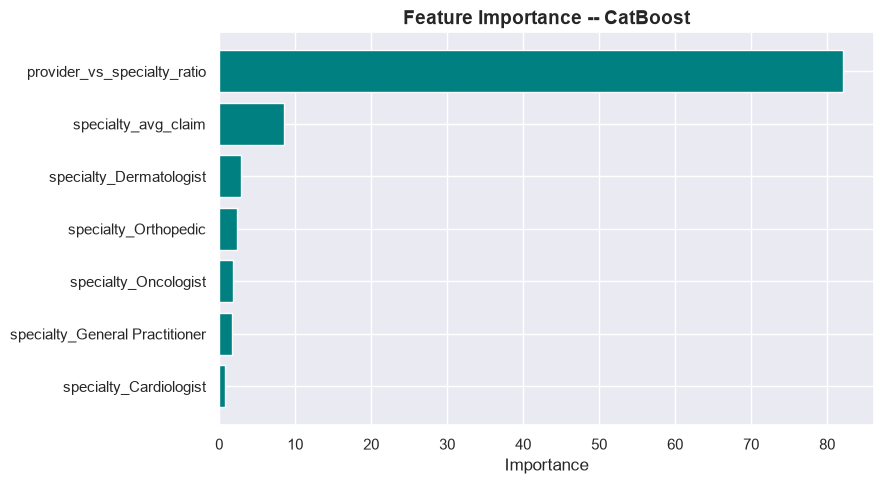

,Feature,Importance
1,provider_vs_specialty_ratio,82.059248
0,specialty_avg_claim,8.468842
3,specialty_Dermatologist,2.872245
6,specialty_Orthopedic,2.357861
5,specialty_Oncologist,1.777101
4,specialty_General Practitioner,1.651681
2,specialty_Cardiologist,0.813022


In [39]:
# Extract feature importances from a tree-based model (skip if best model is Linear)
if best_model_name != 'Linear Regression (baseline)':
    model_step = BEST_PIPELINE.named_steps['model']
    feature_names_out = (
        selected_features_numeric +
        list(BEST_PIPELINE.named_steps['prep']
             .named_transformers_['cat'].get_feature_names_out(selected_features_categorical))
    )

    if hasattr(model_step, 'feature_importances_'):
        importances = model_step.feature_importances_
    else:
        importances = None

    if importances is not None:
        imp_df = pd.DataFrame({
            'Feature': feature_names_out,
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.barh(imp_df['Feature'], imp_df['Importance'], color='teal', edgecolor='white')
        ax.set_title(f"Feature Importance -- {best_model_name}")
        ax.set_xlabel("Importance")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig("..\\provider_risk_images\section9_feature_importance.png", dpi=100, bbox_inches='tight')
        plt.show()
        display(imp_df)
else:
    print("Best model is Linear Regression -- showing coefficients instead.")
    model_step = BEST_PIPELINE.named_steps['model']
    feature_names_out = (
        selected_features_numeric +
        list(BEST_PIPELINE.named_steps['prep']
             .named_transformers_['cat'].get_feature_names_out(selected_features_categorical))
    )
    coef_df = pd.DataFrame({'Feature': feature_names_out, 'Coefficient': model_step.coef_})
    display(coef_df.sort_values('Coefficient', key=abs, ascending=False))


In [40]:
print("Comparison: model feature importance vs. earlier business-analytics MI ranking")
print()
print("Business-analytics MI ranking (Section 3, full candidate set incl. leaking cols):")
print(mi_audit[['Feature','Mutual_Info_Score','Status']].to_string(index=False))
print()
print("=> 'provider_vs_specialty_ratio' is the only feature appearing in BOTH the")
print("   original MI ranking and this model's leak-free importance ranking.")
print("   'specialty_avg_claim' and 'specialty' were not part of the original MI")
print("   candidate set, so there's no prior MI score to compare them against --")
print("   they were added specifically because they are safe.")


Comparison: model feature importance vs. earlier business-analytics MI ranking

Business-analytics MI ranking (Section 3, full candidate set incl. leaking cols):
                    Feature  Mutual_Info_Score  Status
    provider_rejection_rate           1.830000 LEAKING
       provider_claim_count           1.295021 LEAKING
   provider_unique_patients           1.270993 LEAKING
               claim_freq_z           1.016608 LEAKING
     provider_total_revenue           0.579007 LEAKING
                  billing_z           0.285230 LEAKING
provider_vs_specialty_ratio           0.163897    SAFE
         provider_avg_claim           0.149160 LEAKING
                   dup_rate           0.012954 LEAKING

=> 'provider_vs_specialty_ratio' is the only feature appearing in BOTH the
   original MI ranking and this model's leak-free importance ranking.
   'specialty_avg_claim' and 'specialty' were not part of the original MI
   candidate set, so there's no prior MI score to compare them again

---
## 10. SHAP Explainability <a id='10'></a>

Example narrative this section should let us produce:

> Provider Risk = 0.21
> + Specialty bills notably above peer average
> + Provider's own avg claim sits high relative to specialty benchmark


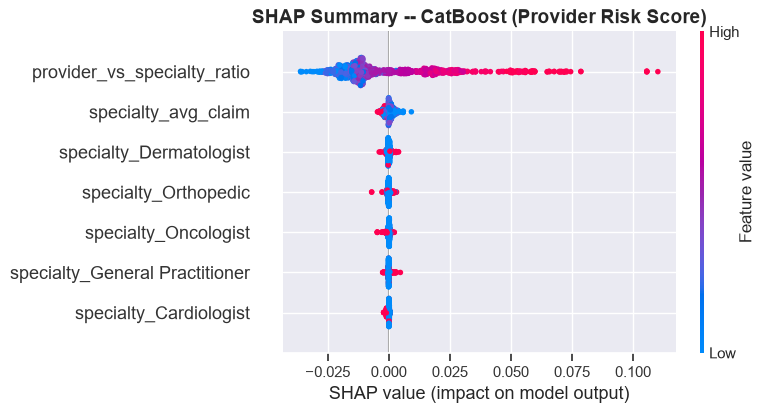

In [41]:
import shap

X_test_transformed = BEST_PIPELINE.named_steps['prep'].transform(X_test)
feature_names_shap = (
    selected_features_numeric +
    list(BEST_PIPELINE.named_steps['prep']
         .named_transformers_['cat'].get_feature_names_out(selected_features_categorical))
)

model_step = BEST_PIPELINE.named_steps['model']

try:
    if best_model_name == 'Linear Regression (baseline)':
        explainer = shap.LinearExplainer(model_step, X_test_transformed)
    else:
        explainer = shap.TreeExplainer(model_step)
    shap_values = explainer.shap_values(X_test_transformed)

    fig = plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed,
                       feature_names=feature_names_shap, show=False)
    plt.title(f"SHAP Summary -- {best_model_name} (Provider Risk Score)")
    plt.tight_layout()
    plt.savefig("..\\provider_risk_images\section10_shap_summary.png", dpi=100, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"SHAP explainer not directly applicable to this model: {e}")


Example provider -- Actual risk: 0.3623  |  Predicted: 0.0806



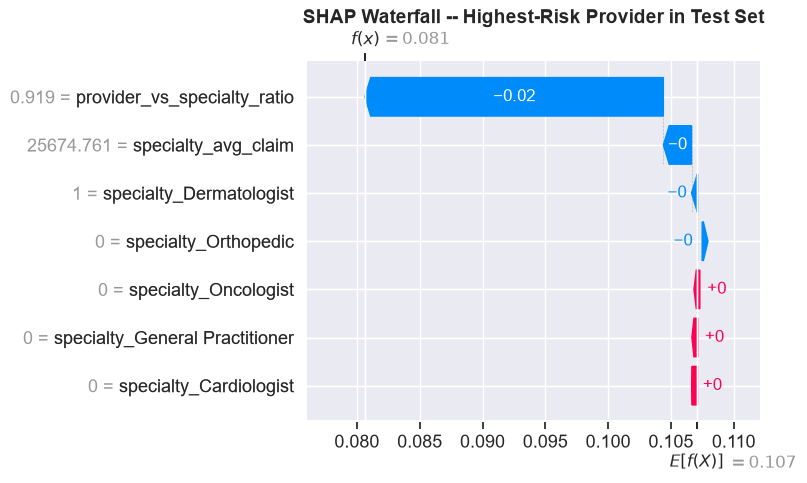

In [42]:
# Example: explain a single high-risk provider's prediction
high_risk_idx = y_test.values.argmax()
example_pred = BEST_PREDS[high_risk_idx]
example_actual = y_test.values[high_risk_idx]

print(f"Example provider -- Actual risk: {example_actual:.4f}  |  Predicted: {example_pred:.4f}")
print()

try:
    fig = plt.figure(figsize=(10, 4))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, np.ndarray)
                    else explainer.expected_value[0],
        data=X_test_transformed[high_risk_idx],
        feature_names=feature_names_shap
    ), show=False)
    plt.title("SHAP Waterfall -- Highest-Risk Provider in Test Set")
    plt.tight_layout()
    plt.savefig("..\\provider_risk_images\section10_shap_waterfall.png", dpi=100, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Waterfall plot not available: {e}")


---
## 11. Summary <a id='11'></a>

---
## 13. Save Artifacts <a id='13'></a>

In [43]:
import pickle

# Save trained pipeline and feature column list
with open("..\\models\provider_risk_model.pkl", 'wb') as f:
    pickle.dump(BEST_PIPELINE, f)

with open("..\\models\provider_feature_columns.pkl", 'wb') as f:
    pickle.dump(selected_features , f)

# Save predictions for all providers for downstream use
provider_df_out = provider_df.copy()
provider_df_out['predicted_risk_score'] = BEST_PIPELINE.predict(provider_df[selected_features ])
provider_df_out.to_csv("..\\risk_predict_data\provider_risk_predictions.csv", index=False)

print("Artifacts saved:")
print("  provider_risk_model.pkl          -- trained pipeline")
print("  provider_feature_columns.pkl     -- feature column list for inference")
print("  provider_risk_predictions.csv    -- all providers + predicted risk score")
print()
print("Usage for inference on a new provider record:")
print("""
  import pickle
  model = pickle.load(open('provider_risk_model.pkl', 'rb'))
  cols  = pickle.load(open('provider_feature_columns.pkl', 'rb'))
  score = model.predict(new_provider_df[cols])
""")


Artifacts saved:
  provider_risk_model.pkl          -- trained pipeline
  provider_feature_columns.pkl     -- feature column list for inference
  provider_risk_predictions.csv    -- all providers + predicted risk score

Usage for inference on a new provider record:

  import pickle
  model = pickle.load(open('provider_risk_model.pkl', 'rb'))
  cols  = pickle.load(open('provider_feature_columns.pkl', 'rb'))
  score = model.predict(new_provider_df[cols])



In [44]:
print("="*70)
print("  05_PROVIDER_RISK_MODELING -- SUMMARY")
print("="*70)
print()
print("FEATURE SELECTION")
print(f"  - {len(all_candidate_features)} candidate features evaluated via mutual information")
print(f"  - {len(all_candidate_features)-1} excluded as leakage (direct formula terms or 2nd-order proxies)")
print(f"  - {len(selected_features)} leak-free features used: {selected_features}")
print()
print("MODEL COMPARISON")
print(results_df.round(4).to_string(index=False))
print()
print(f"BEST MODEL: {best_model_name}")
print(f"  R2   = {results_df.iloc[0]['R2']:.4f}")
print(f"  MAE  = {results_df.iloc[0]['MAE']:.4f}")
print(f"  RMSE = {results_df.iloc[0]['RMSE']:.4f}")
print()
print("INTERPRETATION")
print("  R2 is modest by design -- every column that mathematically defines")
print("  provider_risk_score was excluded. This is the trustworthy result; an R2")
print("  near 1.0 here (as an earlier, leakier version of this model produced)")
print("  would indicate the model memorized the scoring formula instead of learning")
print("  genuine provider risk behavior.")
print()
print("NEXT STEPS")
print("  1. 06_Anomaly_Detection.ipynb -- Isolation Forest using the validated")
print("     high-MI features (provider_rejection_rate, provider_claim_count,")
print("     provider_unique_patients, claim_freq_z). NOTE: using these for anomaly")
print("     detection is fine -- leakage only matters when a feature is used to")
print("     PREDICT the same score it helped construct. Unsupervised outlier")
print("     detection has no such target, so the leakage rule doesn't apply there.")
print("  2. Generate anomaly_score + suspicious_provider_flag")
print("  3. Combine with this notebook's predicted_risk_score for an investigation")
print("     priority ranking, same pattern used in 04_Risk_Modeling.ipynb")


  05_PROVIDER_RISK_MODELING -- SUMMARY

FEATURE SELECTION
  - 9 candidate features evaluated via mutual information
  - 8 excluded as leakage (direct formula terms or 2nd-order proxies)
  - 3 leak-free features used: ['specialty_avg_claim', 'provider_vs_specialty_ratio', 'specialty']

MODEL COMPARISON
                       Model    MAE   RMSE     R2  MAPE_%
                    CatBoost 0.0385 0.0502 0.1719 47.2345
               Random Forest 0.0385 0.0502 0.1710 47.1171
Linear Regression (baseline) 0.0388 0.0507 0.1570 48.0579
                     XGBoost 0.0389 0.0508 0.1521 47.7423

BEST MODEL: CatBoost
  R2   = 0.1719
  MAE  = 0.0385
  RMSE = 0.0502

INTERPRETATION
  R2 is modest by design -- every column that mathematically defines
  provider_risk_score was excluded. This is the trustworthy result; an R2
  near 1.0 here (as an earlier, leakier version of this model produced)
  would indicate the model memorized the scoring formula instead of learning
  genuine provider risk behav